# EDA — Diputados México (todas las legislaturas)
Carga automática del directorio ETL más reciente.

In [10]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load — most recent ETL snapshot

In [11]:
ETL_ROOT = Path('/home/miso/Projects/diputrax/data/source/')

# directories named YYYYMMDD_HHMMSS — sort lexicographically = chronologically
snapshots = sorted([d for d in ETL_ROOT.iterdir() if d.is_dir()])
latest = snapshots[-1]
print(f'Snapshots found : {[d.name for d in snapshots]}')
print(f'Using           : {latest.name}')

Snapshots found : ['20260419_183513']
Using           : 20260419_183513


In [12]:
csv_files = sorted(latest.glob('*.csv'))
print(f'{len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {f.name}')

10 CSV files:
  LIX_20260419_183514.csv
  LVIII_20260419_183514.csv
  LVII_20260419_183513.csv
  LXIII_20260419_183515.csv
  LXII_20260419_183515.csv
  LXIV_20260419_183515.csv
  LXI_20260419_183514.csv
  LXVI_20260419_183515.csv
  LXV_20260419_183515.csv
  LX_20260419_183514.csv


In [13]:
frames = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    frames.append(df_tmp)

df = pd.concat(frames, ignore_index=True)
print(f'Combined shape: {df.shape}')
df.head(3)

Combined shape: (5000, 138)


,diputado_id,referencia,legislatura_nombre,legislatura_num,partido_nombre,nombre,partido,suplente_referencia,en_licencia,y_nacimiento,edad_al_tomar_cargo,grado_estudios_ord,mayoria_relativa,tiene_suplente,area_formacion,fue_diputado_local,fue_diputado_federal,fue_senador,n_cargos_legislativos_prev,entidad_codigo,distrito_circ,n_comisiones,n_comisiones_especiales,n_presidencias,n_secretarias,...,lider_juvenil_partido,lider_juvenil_gobierno,miembro_org_juvenil,nivel_liderazgo_juvenil,tiene_posgrado,tiene_doctorado,estudios_en_extranjero,univ_publica,univ_privada,univ_extranjera,acad_unam,acad_itesm,acad_itam,acad_ibero,acad_udg,acad_ipn,acad_uam,acad_anahuac,acad_uanl,acad_uv,n_trayectoria_legislativa,n_trayectoria_politica,n_trayectoria_empresarial,n_investigacion_docencia,n_organos_gobierno
0,1c230671710f,569096,LIX,59,Partido Revolucionario Institucional,Abel Echeverría Pineda,PRI,2178850,False,1954.00,49.00,0,1,1,Otra,0,0,0,0,GRO,1 (Coyuca de Catalán),6,3,0,0,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,6,0,0,0
1,f2e201f17d25,569639,LIX,59,Partido Revolucionario Institucional,Juan Manuel Vega Rayet,PRI,2178954,False,1959.00,44.00,0,1,1,Otra,0,0,0,0,PUE,14 (Izúcar de Matamoros),3,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,11,6,0,0
2,f6992bc28127,570142,LIX,59,Partido Revolucionario Institucional,Homero Díaz Rodríguez,PRI,1605914,False,1959.00,44.00,0,0,1,Otra,0,0,0,0,DESCONOCIDO,NaN,2,0,0,1,...,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,8,4,0,0


## 2. Schema & data quality

In [14]:
print('Dtypes')
print(df.dtypes.value_counts())
print()
print('Shape per legislatura')
print(df.groupby('legislatura_num').size().sort_index())

Dtypes
int64      127
str          8
float64      2
bool         1
Name: count, dtype: int64

Shape per legislatura
legislatura_num
57    500
58    500
59    500
60    500
61    500
62    500
63    500
64    500
65    500
66    500
dtype: int64


In [37]:
#Data info report

report = pd.DataFrame({
    "dtype": df.dtypes,
    "non_nulls": df.notnull().sum(),
    "nulls": df.isnull().sum(),
    "null_pct": df.isnull().mean() * 100,
    "unique": df.nunique()
}).sort_values("null_pct", ascending=False)

report

,dtype,non_nulls,nulls,null_pct,unique
edad_al_tomar_cargo,float64,4490,510,10.20,62
y_nacimiento,float64,4494,506,10.12,79
distrito_circ,str,4789,211,4.22,485
legislatura_nombre,str,5000,0,0.00,10
referencia,int64,5000,0,0.00,5000
...,...,...,...,...,...
n_trayectoria_legislativa,int64,5000,0,0.00,11
n_trayectoria_politica,int64,5000,0,0.00,40
n_trayectoria_empresarial,int64,5000,0,0.00,24
n_investigacion_docencia,int64,5000,0,0.00,10


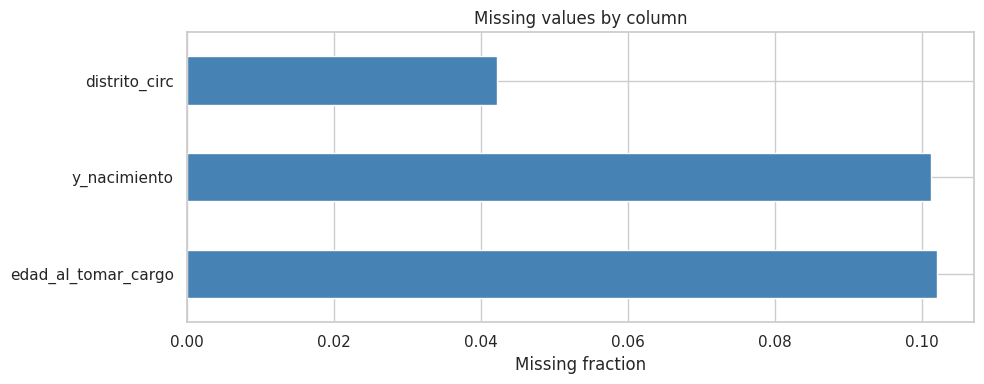

Columns with nulls: 3


In [15]:
# missing values heatmap
miss = df.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(miss_nonzero) * 0.3)))
miss_nonzero.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Missing fraction')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.show()
print(f'Columns with nulls: {len(miss_nonzero)}')

In [16]:
# quick numeric summary
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].describe().T.sort_values('mean', ascending=False).head(30)

,count,mean,std,min,25%,50%,75%,max
referencia,5000.00,5644089.10,4139062.44,18.00,570009.25,9215555.00,9222967.50,9229432.00
suplente_referencia,5000.00,5476572.65,3817869.01,0.00,2178349.75,6911007.00,9222441.50,9229431.00
y_nacimiento,4494.00,1964.27,12.80,1902.00,1955.00,1964.00,1973.00,2003.00
legislatura_num,5000.00,61.50,2.87,57.00,59.00,61.50,64.00,66.00
edad_al_tomar_cargo,4490.00,46.20,10.44,21.00,39.00,46.00,53.00,85.00
n_trayectoria_politica,5000.00,6.12,5.30,0.00,2.00,5.00,9.00,44.00
n_comisiones,5000.00,3.97,1.71,0.00,3.00,4.00,5.00,18.00
grado_estudios_ord,5000.00,3.64,2.99,0.00,0.00,6.00,6.00,9.00
n_trayectoria_admin,5000.00,3.17,3.13,0.00,1.00,2.00,5.00,25.00
nivel_cargo_max,5000.00,2.43,1.77,0.00,0.00,3.00,4.00,5.00


## 3. Legislatura overview

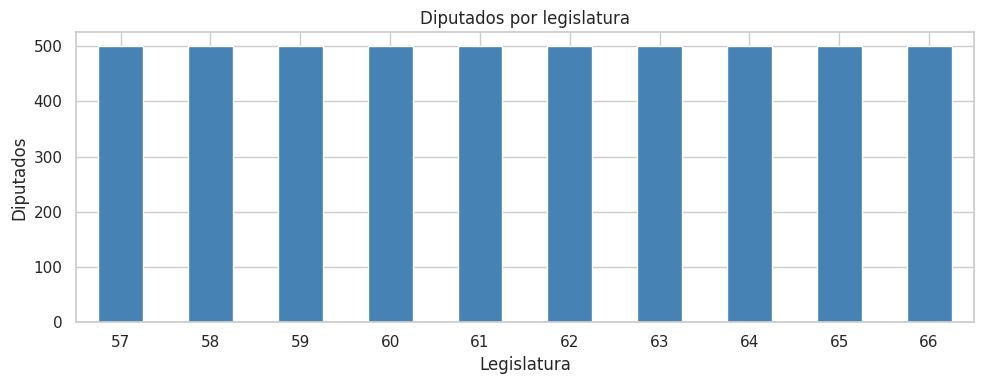

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = df.groupby('legislatura_num').size()
counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Diputados')
ax.set_title('Diputados por legislatura')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Partido distribution

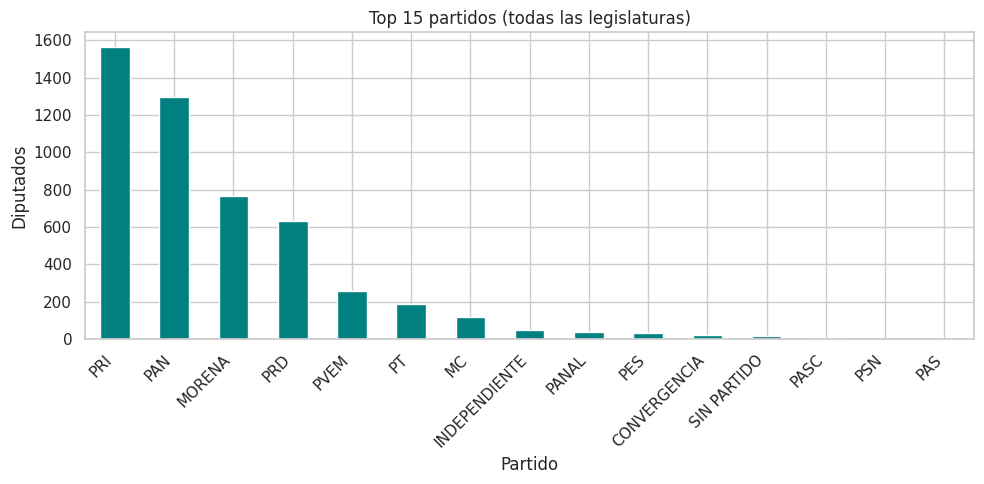

In [18]:
top_partidos = df['partido'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_partidos.plot.bar(ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 15 partidos (todas las legislaturas)')
ax.set_xlabel('Partido')
ax.set_ylabel('Diputados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

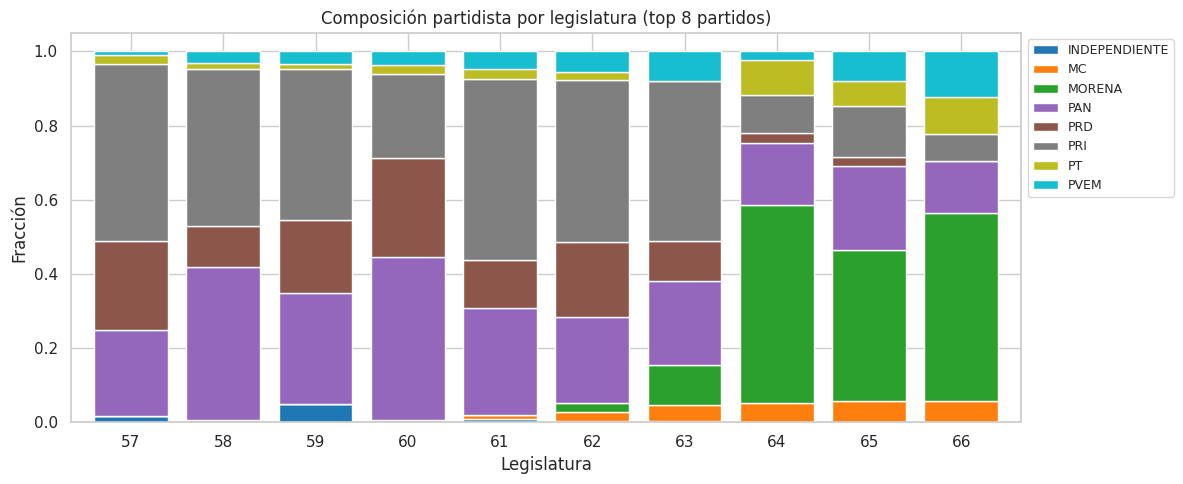

In [19]:
# partido share per legislatura (top 8 parties overall)
top8 = df['partido'].value_counts().head(8).index.tolist()
piv = (
    df[df['partido'].isin(top8)]
    .groupby(['legislatura_num', 'partido'])
    .size()
    .unstack(fill_value=0)
)
piv_pct = piv.div(piv.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
piv_pct.plot.bar(stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Composición partidista por legislatura (top 8 partidos)')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Fracción')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Género & elección

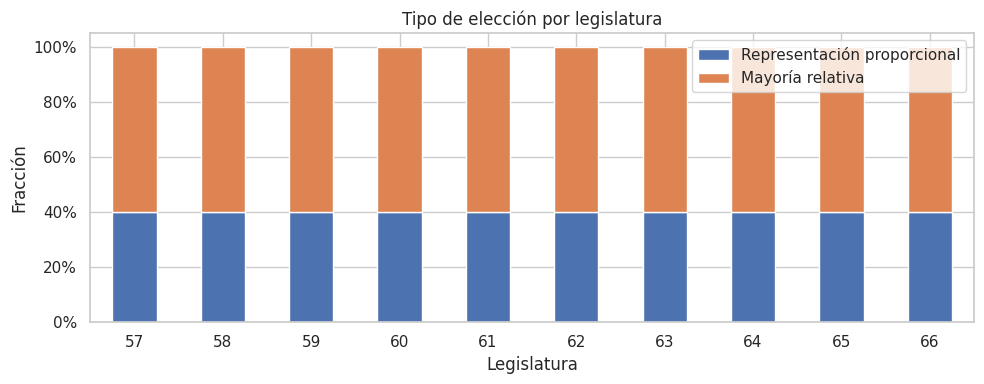

In [20]:
if 'mayoria_relativa' in df.columns:
    mr = df.groupby(['legislatura_num', 'mayoria_relativa']).size().unstack(fill_value=0)
    mr.columns = ['Representación proporcional', 'Mayoría relativa']
    mr_pct = mr.div(mr.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    mr_pct.plot.bar(stacked=True, ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title('Tipo de elección por legislatura')
    ax.set_xlabel('Legislatura')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(loc='upper right')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Edad al tomar cargo

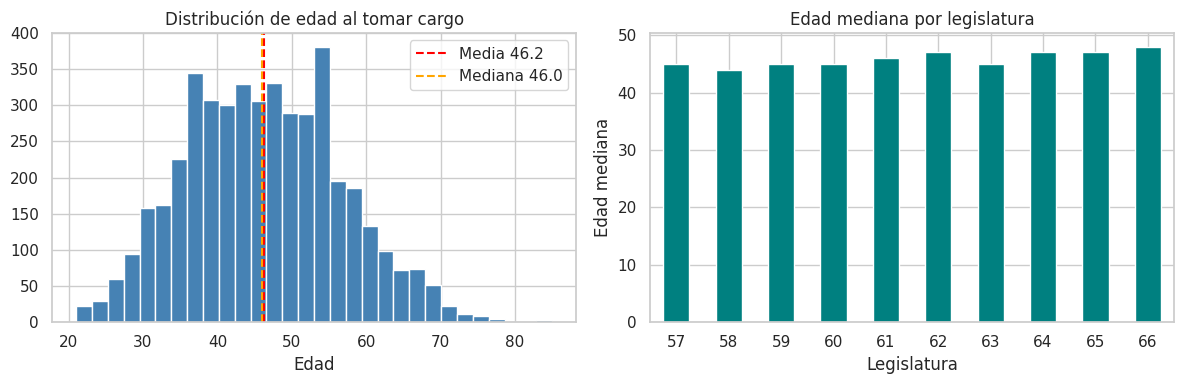

count   4490.00
mean      46.20
std       10.44
min       21.00
25%       39.00
50%       46.00
75%       53.00
max       85.00
Name: edad_al_tomar_cargo, dtype: float64


In [21]:
age_col = 'edad_al_tomar_cargo'
if age_col in df.columns:
    age = df[age_col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # overall distribution
    axes[0].hist(age, bins=30, color='steelblue', edgecolor='white')
    axes[0].axvline(age.mean(), color='red', linestyle='--', label=f'Media {age.mean():.1f}')
    axes[0].axvline(age.median(), color='orange', linestyle='--', label=f'Mediana {age.median():.1f}')
    axes[0].set_title('Distribución de edad al tomar cargo')
    axes[0].set_xlabel('Edad')
    axes[0].legend()

    # by legislatura
    leg_age = df.groupby('legislatura_num')[age_col].median()
    leg_age.plot.bar(ax=axes[1], color='teal', edgecolor='white')
    axes[1].set_title('Edad mediana por legislatura')
    axes[1].set_xlabel('Legislatura')
    axes[1].set_ylabel('Edad mediana')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(age.describe())

## 7. Escolaridad

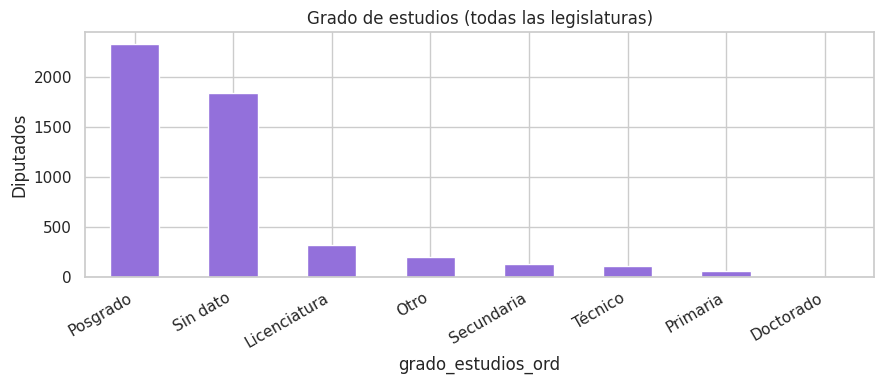

In [22]:
edu_map = {
    0: 'Sin dato',
    1: 'Primaria',
    2: 'Secundaria',
    3: 'Bachillerato',
    4: 'Técnico',
    5: 'Licenciatura',
    6: 'Posgrado',
    7: 'Doctorado',
}
if 'grado_estudios_ord' in df.columns:
    edu = df['grado_estudios_ord'].map(edu_map).fillna('Otro')
    counts_edu = edu.value_counts()

    fig, ax = plt.subplots(figsize=(9, 4))
    counts_edu.plot.bar(ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('Grado de estudios (todas las legislaturas)')
    ax.set_ylabel('Diputados')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Área de formación

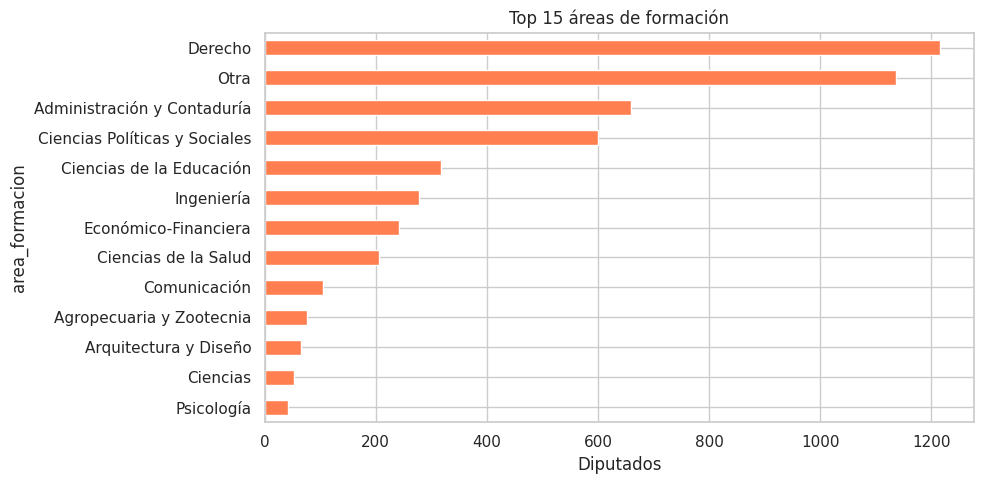

In [23]:
if 'area_formacion' in df.columns:
    af = df['area_formacion'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    af.plot.barh(ax=ax, color='coral', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title('Top 15 áreas de formación')
    ax.set_xlabel('Diputados')
    plt.tight_layout()
    plt.show()

## 9. Experiencia legislativa previa

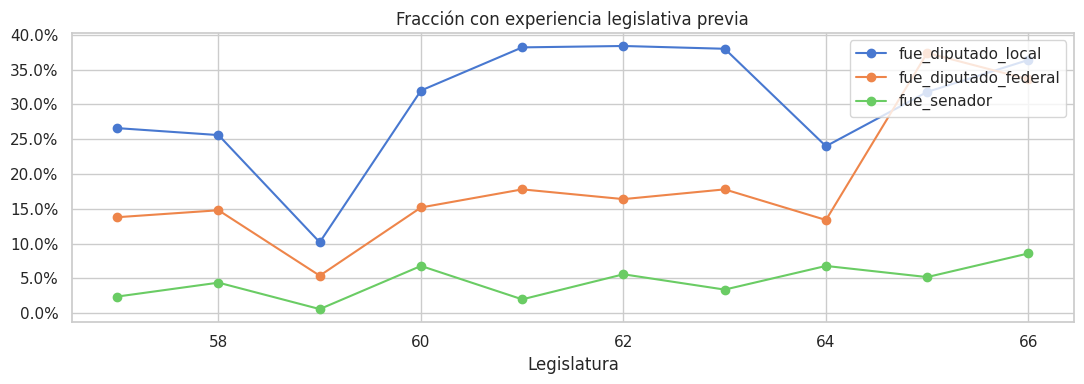

In [24]:
exp_cols = ['fue_diputado_local', 'fue_diputado_federal', 'fue_senador']
exp_cols = [c for c in exp_cols if c in df.columns]

if exp_cols:
    exp_by_leg = df.groupby('legislatura_num')[exp_cols].mean()

    fig, ax = plt.subplots(figsize=(11, 4))
    exp_by_leg.plot(ax=ax, marker='o')
    ax.set_title('Fracción con experiencia legislativa previa')
    ax.set_xlabel('Legislatura')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

## 10. Participación en comisiones

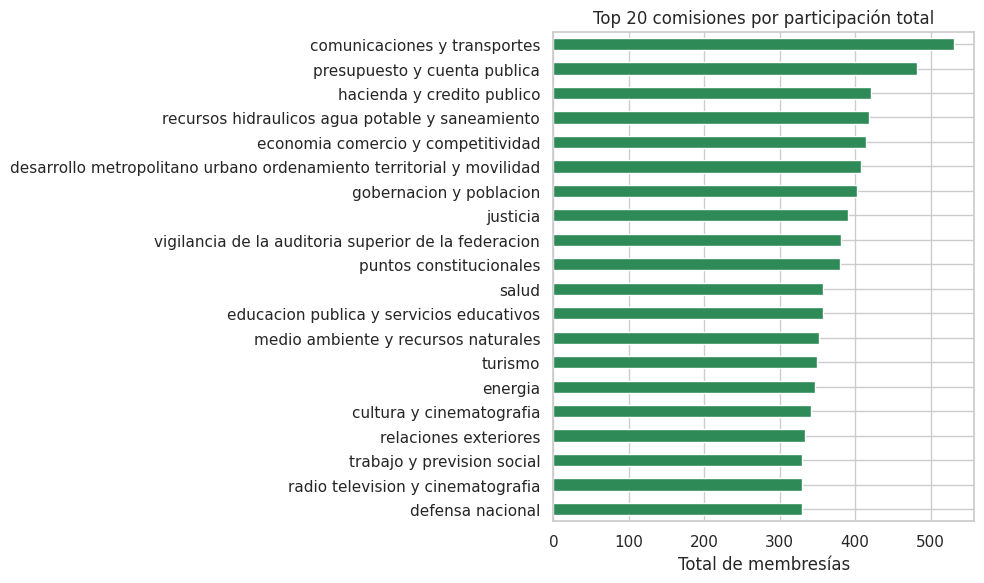

In [25]:
com_prefix = 'comision_'
com_cols = [c for c in df.columns if c.startswith(com_prefix)]

# top 20 commissions by total participation across all legislaturas
com_totals = df[com_cols].sum().sort_values(ascending=False).head(20)
com_totals.index = com_totals.index.str.replace(com_prefix, '', regex=False).str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(10, 6))
com_totals.plot.barh(ax=ax, color='seagreen', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 comisiones por participación total')
ax.set_xlabel('Total de membresías')
plt.tight_layout()
plt.show()

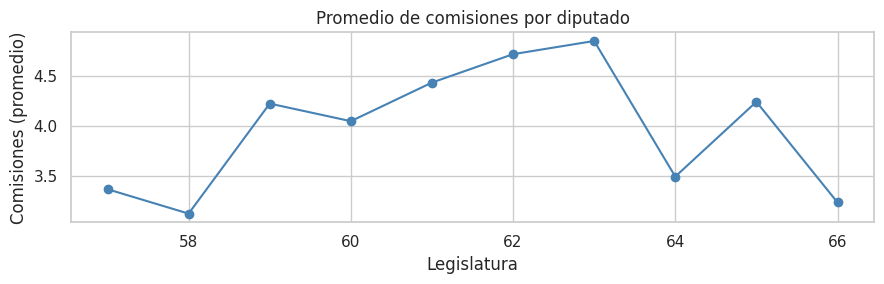

In [26]:
# avg commissions per diputado over time
if 'n_comisiones' in df.columns:
    avg_com = df.groupby('legislatura_num')['n_comisiones'].mean()
    fig, ax = plt.subplots(figsize=(9, 3))
    avg_com.plot(marker='o', ax=ax, color='steelblue')
    ax.set_title('Promedio de comisiones por diputado')
    ax.set_xlabel('Legislatura')
    ax.set_ylabel('Comisiones (promedio)')
    plt.tight_layout()
    plt.show()

## 11. Trayectoria administrativa

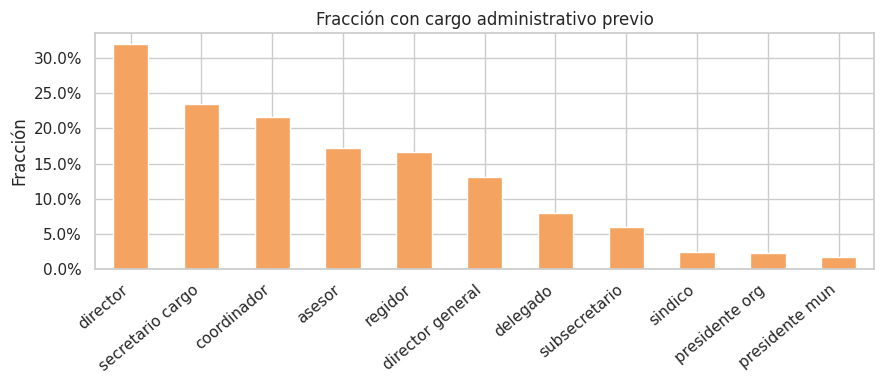

In [27]:
admin_cols = [
    'fue_presidente_mun', 'fue_presidente_org', 'fue_director_general',
    'fue_secretario_cargo', 'fue_subsecretario', 'fue_director',
    'fue_coordinador', 'fue_delegado', 'fue_asesor', 'fue_regidor', 'fue_sindico',
]
admin_cols = [c for c in admin_cols if c in df.columns]

admin_pct = df[admin_cols].mean().sort_values(ascending=False)
admin_pct.index = admin_pct.index.str.replace('fue_', '', regex=False).str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(9, 4))
admin_pct.plot.bar(ax=ax, color='sandybrown', edgecolor='white')
ax.set_title('Fracción con cargo administrativo previo')
ax.set_ylabel('Fracción')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## 12. Perfil académico

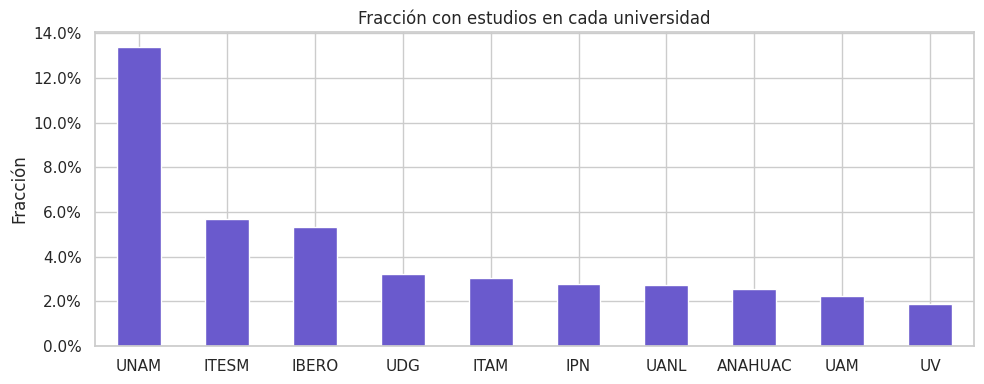

In [28]:
acad_cols = [c for c in df.columns if c.startswith('acad_')]
if acad_cols:
    acad_pct = df[acad_cols].mean().sort_values(ascending=False)
    acad_pct.index = acad_pct.index.str.replace('acad_', '', regex=False).str.upper()

    fig, ax = plt.subplots(figsize=(10, 4))
    acad_pct.plot.bar(ax=ax, color='slateblue', edgecolor='white')
    ax.set_title('Fracción con estudios en cada universidad')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 13. Correlation heatmap — numeric features

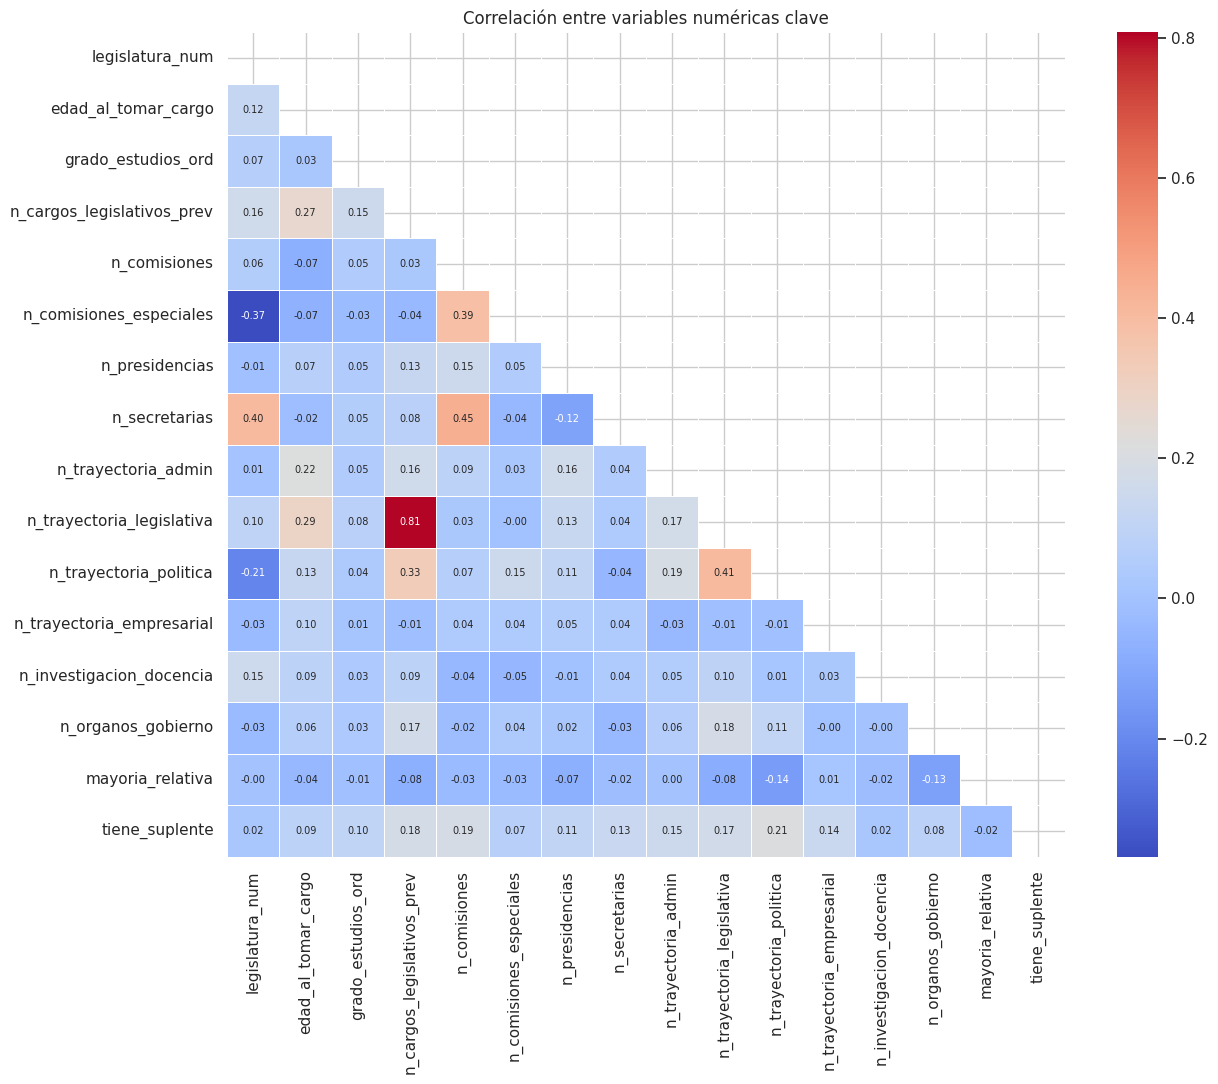

In [29]:
key_numeric = [
    'legislatura_num', 'edad_al_tomar_cargo', 'grado_estudios_ord',
    'n_cargos_legislativos_prev', 'n_comisiones', 'n_comisiones_especiales',
    'n_presidencias', 'n_secretarias',
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
    'n_investigacion_docencia', 'n_organos_gobierno',
    'mayoria_relativa', 'tiene_suplente',
]
key_numeric = [c for c in key_numeric if c in df.columns]

corr = df[key_numeric].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlación entre variables numéricas clave')
plt.tight_layout()
plt.show()

## 14. Pairplot — trayectorias

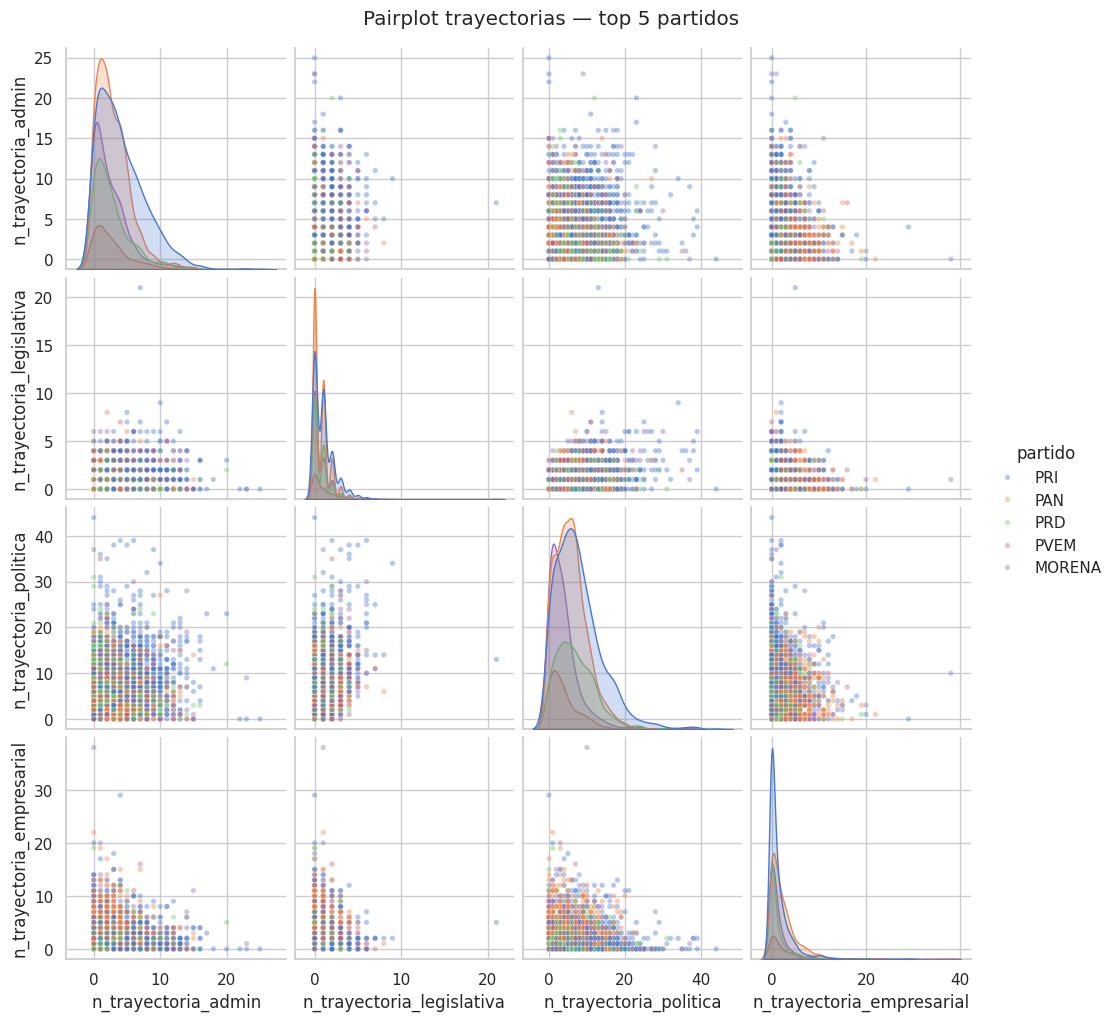

In [30]:
traj_cols = [
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
]
traj_cols = [c for c in traj_cols if c in df.columns]

if traj_cols:
    sample = df[traj_cols + ['partido']].dropna()
    top5 = sample['partido'].value_counts().head(5).index
    sample = sample[sample['partido'].isin(top5)]

    g = sns.pairplot(sample, hue='partido', vars=traj_cols, plot_kws={'alpha': 0.4, 's': 15})
    g.figure.suptitle('Pairplot trayectorias — top 5 partidos', y=1.02)
    plt.show()

## 15. Key stats summary

In [31]:
summary = {
    'Total diputados (filas)': len(df),
    'Legislaturas': df['legislatura_num'].nunique(),
    'Partidos únicos': df['partido'].nunique(),
    'Edad media': df['edad_al_tomar_cargo'].mean() if 'edad_al_tomar_cargo' in df.columns else 'N/A',
    'Pct mayoría relativa': df['mayoria_relativa'].mean() if 'mayoria_relativa' in df.columns else 'N/A',
    'Pct con posgrado': df['tiene_posgrado'].mean() if 'tiene_posgrado' in df.columns else 'N/A',
    'Pct con doctorado': df['tiene_doctorado'].mean() if 'tiene_doctorado' in df.columns else 'N/A',
    'Pct estudios extranjero': df['estudios_en_extranjero'].mean() if 'estudios_en_extranjero' in df.columns else 'N/A',
    'Promedio comisiones': df['n_comisiones'].mean() if 'n_comisiones' in df.columns else 'N/A',
}

for k, v in summary.items():
    val = f'{v:.3f}' if isinstance(v, float) else v
    print(f'{k:<35} {val}')

Total diputados (filas)             5000
Legislaturas                        10
Partidos únicos                     16
Edad media                          46.202
Pct mayoría relativa                0.600
Pct con posgrado                    0.323
Pct con doctorado                   0.053
Pct estudios extranjero             0.081
Promedio comisiones                 3.970
